In [7]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import functools

In [8]:
class Distribution:  # abstract
    def __init__(self, *args, **kwargs):
        self._dist = Counter()
        self._generate_dist(*args, **kwargs)
        self._build_ranks()
    
    def _generate_dist(self, *args, **kwargs):
        # should be implemented by subclasses
        pass
    
    def _build_ranks(self):
        self._ranks = [0] * 101
        cur_rank = 0
        last_count = 1
        for i in range(100, -1, -1):
            if self._dist[i] != 0:
                cur_rank += last_count
                last_count = self._dist[i]
            self._ranks[i] = cur_rank
        self.max_rank = cur_rank

    def __add__(self, other):
        result = Distribution()
        result._dist = self._dist + other._dist
        result._build_ranks()
        return result

    @property
    def size(self):
        return sum(self._dist.values())

    def get_multiplier(self, value):
        return 0.9 - 0.8 * (self._ranks[value] - 1) / (self.max_rank - 1)


class RandomDist(Distribution):
    def _generate_dist(self, low, high, n):
        self.samples = []
        for i in range(n):
            sample = np.random.randint(low, high + 1)
            self._dist[sample] += 1
            self.samples.append(sample)


class NormalDist(Distribution):
    def _generate_dist(self, mean, std, n):
        self.samples = []
        for i in range(n):
            sample = int(np.random.normal(mean, std))
            sample = max(0, min(100, sample))
            self._dist[sample] += 1
            self.samples.append(sample)


class FixedDist(Distribution):
    def _generate_dist(self, val, n):
        assert val >= 0 and val <= 100
        self._dist[val] = n


class AllDist(Distribution):
    def _generate_dist(self, n):
        for i in range(101):
            self._dist[i] = n


test_fixed_dist1 = FixedDist(50, 10)
test_fixed_dist2 = FixedDist(70, 20)
test_fixed_dist3 = test_fixed_dist1 + test_fixed_dist2
assert test_fixed_dist3._ranks[70] == 1
assert test_fixed_dist3._ranks[50] == 21
assert abs(test_fixed_dist3.get_multiplier(70) - 0.9) < 1e-10
assert abs(test_fixed_dist3.get_multiplier(50) - 0.1) < 1e-10
assert test_fixed_dist3.size == 30

test_random_dist = RandomDist(20, 50, 100)
actual = [(i, test_random_dist.get_multiplier(i)) for i in sorted(set(test_random_dist.samples), reverse=True)]
for i in range(len(actual) - 1):
    assert (actual[i + 1][1] - actual[i][1]) / (0.8 / 99) - test_random_dist._dist[actual[i][0]] < 1e-6

In [9]:
def _get_pnl_without_speed(research: int, scale: int) -> float:
    return (200_000 * np.log(1 + research) / np.log(1 + 100)) * (scale * 7 / 100)

def get_pnl(research: int, scale: int, speed: int, dist: Distribution) -> float:
    assert research >= 0 and research <= 100
    assert scale >= 0 and scale <= 100
    assert speed >= 0 and speed <= 100
    assert research + scale + speed <= 100

    return _get_pnl_without_speed(research, scale) * dist.get_multiplier(speed) \
        - (research + scale + speed) / 100 * 50_000

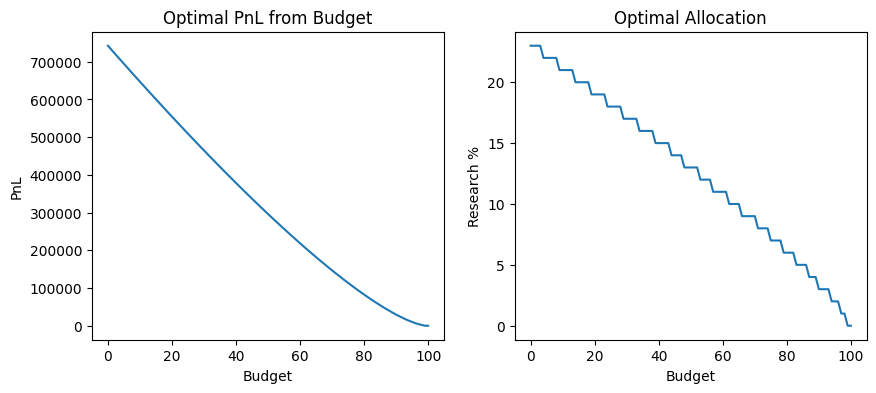

In [10]:
# optimal allocation if not taking into account speed
# here budget = research + scale
@functools.cache
def get_optimal_without_speed(budget_left: int) -> tuple[int, tuple[int, int]]:
    assert budget_left >= 0 and budget_left <= 100
    max_allocation = None
    max_pnl = -1
    for i in range(budget_left + 1):
        pnl = _get_pnl_without_speed(i, budget_left - i)
        if max_pnl < pnl:
            max_allocation = (i, budget_left - i)
            max_pnl = pnl
    return max_pnl, max_allocation


interval = range(0, 101, 1)
optimal_alloc = [get_optimal_without_speed(100 - i) for i in interval]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes.flatten()

axes[0].plot(interval, [t[0] for t in optimal_alloc])
axes[0].set_title("Optimal PnL from Budget")
axes[0].set_xlabel("Budget")
axes[0].set_ylabel("PnL")

axes[1].plot(interval, [t[1][0] for t in optimal_alloc])
axes[1].set_title("Optimal Allocation")
axes[1].set_xlabel("Budget")
axes[1].set_ylabel("Research %")

plt.show()

In [11]:
def draw(*args: Distribution):
    interval = range(0, 101, 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes.flatten()

    axes[0].set_title("Speed Distribution")
    axes[0].set_xlabel("Speed")
    axes[0].set_ylabel("Probability")
    axes[0].set_ylim(bottom=0)

    axes[1].set_title("PnL Given Speed Distribution")
    axes[1].set_xlabel("Speed")
    axes[1].set_ylabel("PnL")

    for dist in args:
        pnls = [get_pnl(*optimal_alloc[s][1], s, dist) for s in interval]
        sorted_pnls = sorted([(p, s) for s, p in zip(interval, pnls)], reverse=True)
        print("Top 5 PnL with Speed Distribution:")
        for p, s in sorted_pnls[:5]:
            print(f"Speed: {s}, PnL: {p}")
        axes[0].plot(interval, [dist._dist[i] / dist.size for i in interval])
        axes[1].plot(interval, pnls)

Top 5 PnL with Speed Distribution:
Speed: 36, PnL: 110065.31395662151
Speed: 35, PnL: 110030.93566754149
Speed: 37, PnL: 109962.17908938142
Speed: 34, PnL: 109859.04422214135
Speed: 38, PnL: 109721.53106582124


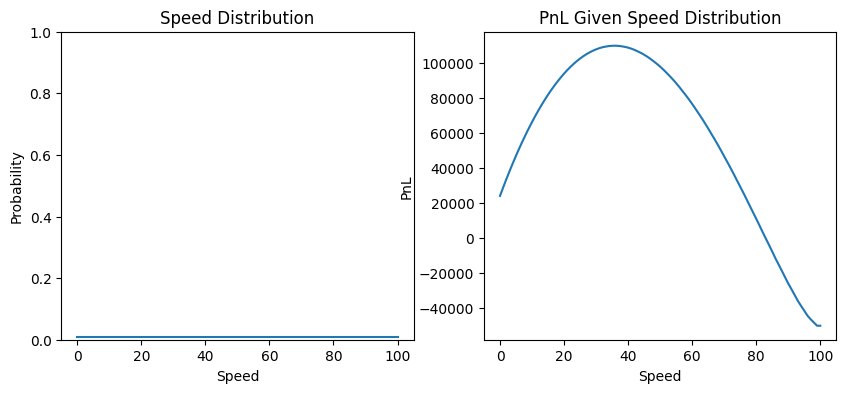

In [12]:
dist = AllDist(10)
draw(dist)

Top 5 PnL with Speed Distribution:
Speed: 32, PnL: 122246.75995571446
Speed: 29, PnL: 122079.87728170893
Speed: 30, PnL: 121888.27124859151
Speed: 28, PnL: 121412.98479627082
Speed: 33, PnL: 121341.70841679559


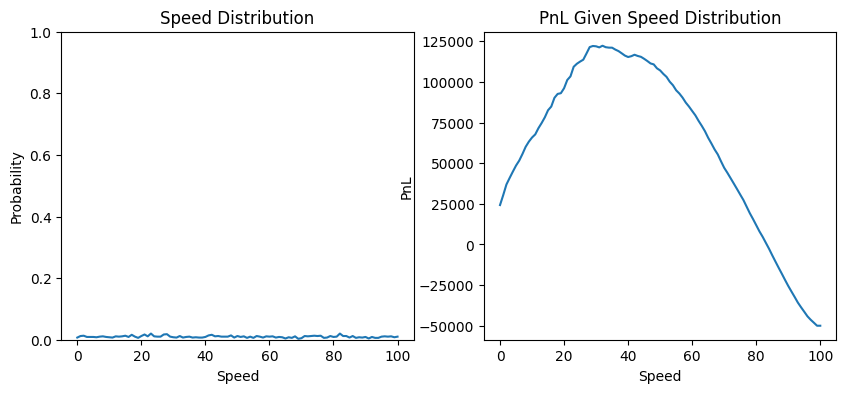

In [13]:
dist = RandomDist(0, 100, 1000)
draw(dist)

Top 5 PnL with Speed Distribution:
Speed: 33, PnL: 268069.9639681068
Speed: 35, PnL: 267395.3944911118
Speed: 32, PnL: 267240.7526200143
Speed: 34, PnL: 266271.62177520426
Speed: 36, PnL: 264898.2177642181


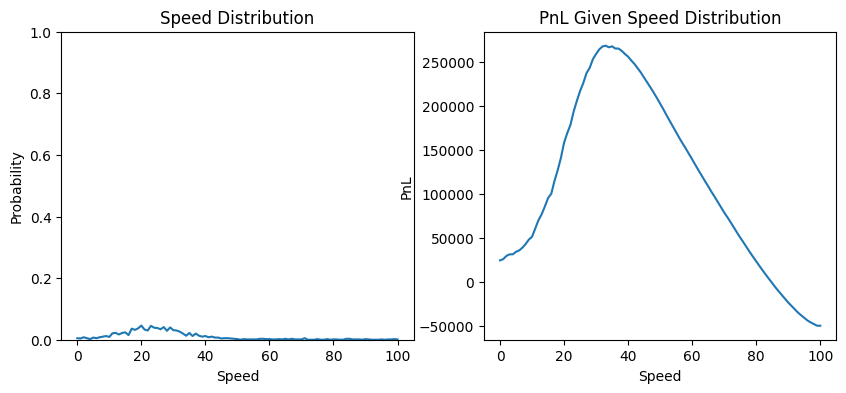

In [14]:
dist = RandomDist(0, 100, 100) + NormalDist(25, 10, 900)
draw(dist)

Top 5 PnL with Speed Distribution:
Speed: 21, PnL: 382539.3816191983
Speed: 23, PnL: 382501.0989580359
Speed: 22, PnL: 382213.9789993178
Speed: 24, PnL: 379668.3605907363
Speed: 20, PnL: 379517.7858631657


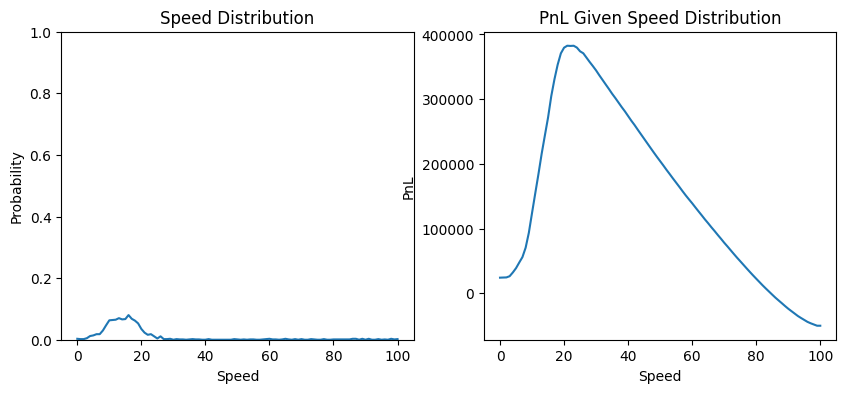

In [15]:
dist = RandomDist(0, 100, 100) + NormalDist(15, 5, 900)
draw(dist)

Top 5 PnL with Speed Distribution:
Speed: 43, PnL: 193450.8875527716
Speed: 44, PnL: 193315.46411980395
Speed: 45, PnL: 192112.0404992436
Speed: 42, PnL: 191709.76148593312
Speed: 46, PnL: 190948.12736690958


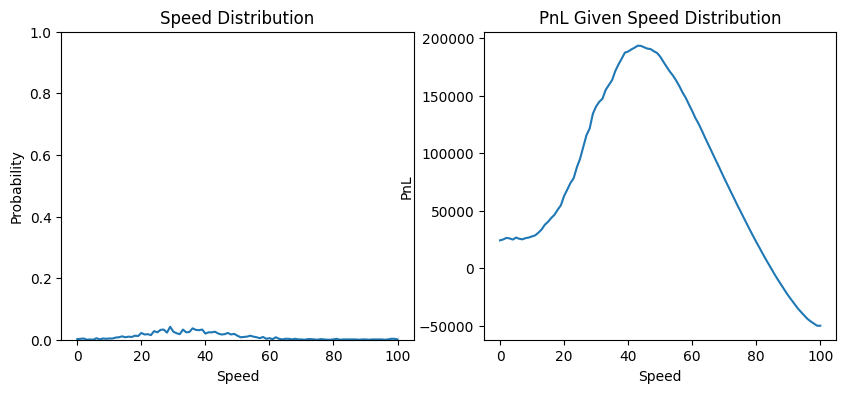

In [16]:
dist = RandomDist(0, 100, 100) + NormalDist(35, 12, 900)
draw(dist)

Top 5 PnL with Speed Distribution:
Speed: 36, PnL: 266613.6247637223
Speed: 35, PnL: 266403.5352193444
Speed: 34, PnL: 265568.3858735113
Speed: 33, PnL: 265558.09241053637
Speed: 37, PnL: 264913.8093592097
Top 5 PnL with Speed Distribution:
Speed: 23, PnL: 377895.4599146628
Speed: 24, PnL: 376382.82080555253
Speed: 22, PnL: 373668.5539890849
Speed: 25, PnL: 372704.4218703645
Speed: 21, PnL: 369485.3558369727
Top 5 PnL with Speed Distribution:
Speed: 43, PnL: 202228.99457706462
Speed: 42, PnL: 200986.77781882655
Speed: 44, PnL: 200229.7995594119
Speed: 41, PnL: 200000.75773257244
Speed: 45, PnL: 198591.7605683619


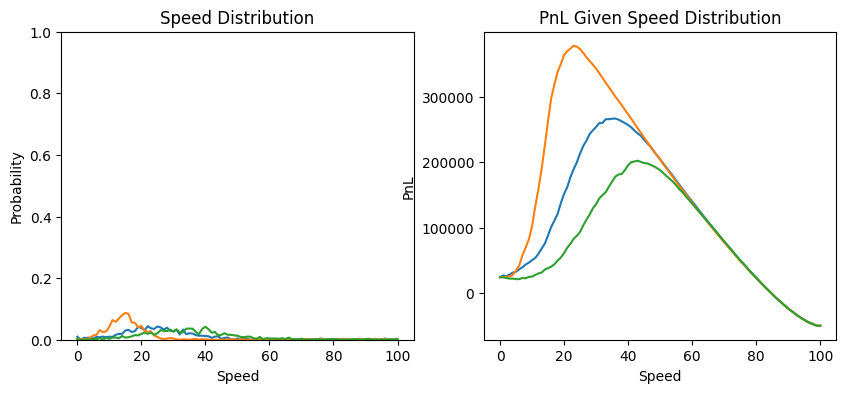

In [17]:
dists = [
    RandomDist(0, 100, 100) + NormalDist(25, 10, 900),
    RandomDist(0, 100, 100) + NormalDist(15, 5, 900),
    RandomDist(0, 100, 100) + NormalDist(35, 12, 900)
]
draw(*dists)

Top 5 PnL with Speed Distribution:
Speed: 33, PnL: 313664.19923825783
Speed: 31, PnL: 311780.71095162746
Speed: 32, PnL: 311627.1180111986
Speed: 34, PnL: 310257.9717783466
Speed: 35, PnL: 304739.03473008843
Top 5 PnL with Speed Distribution:
Speed: 33, PnL: 289681.60462761833
Speed: 34, PnL: 289170.9588399689
Speed: 35, PnL: 288808.0385866416
Speed: 36, PnL: 287521.0078545331
Speed: 32, PnL: 287146.19474764063
Top 5 PnL with Speed Distribution:
Speed: 35, PnL: 272026.3204162977
Speed: 36, PnL: 271400.8695614133
Speed: 37, PnL: 270527.64725369983
Speed: 34, PnL: 269650.9836758081
Speed: 33, PnL: 267323.0149260097
Top 5 PnL with Speed Distribution:
Speed: 37, PnL: 253512.3025792216
Speed: 36, PnL: 253268.86241035542
Speed: 38, PnL: 252513.23808692134
Speed: 39, PnL: 251381.95171059098
Speed: 40, PnL: 250670.6739784673
Top 5 PnL with Speed Distribution:
Speed: 34, PnL: 245671.00685582845
Speed: 35, PnL: 245662.14647204493
Speed: 33, PnL: 245489.3825859544
Speed: 36, PnL: 245072.044912062

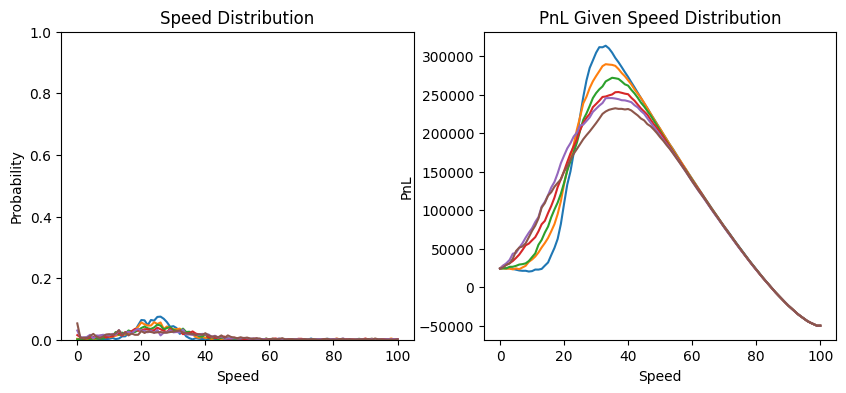

In [18]:
dists = [
    RandomDist(0, 100, 100) + NormalDist(25, std, 900)
    for std in range(5, 16, 2)
]
draw(*dists)

Top 5 PnL with Speed Distribution:
Speed: 18, PnL: 419904.08264091687
Speed: 19, PnL: 417341.7254674492
Speed: 17, PnL: 413490.9996272072
Speed: 20, PnL: 411137.0427925488
Speed: 21, PnL: 404014.49687486887
Top 5 PnL with Speed Distribution:
Speed: 20, PnL: 400964.7476049277
Speed: 21, PnL: 400558.126400605
Speed: 19, PnL: 397528.93487846886
Speed: 22, PnL: 397342.4531180971
Speed: 23, PnL: 391026.6342777995
Top 5 PnL with Speed Distribution:
Speed: 22, PnL: 387806.8934967583
Speed: 23, PnL: 387153.35378120013
Speed: 21, PnL: 386914.5428949014
Speed: 24, PnL: 384240.958937814
Speed: 20, PnL: 379072.97780013597
Top 5 PnL with Speed Distribution:
Speed: 24, PnL: 378459.1919806465
Speed: 23, PnL: 378317.9683914978
Speed: 22, PnL: 374098.3470948308
Speed: 25, PnL: 373520.6505391946
Speed: 21, PnL: 368611.2003676589
Top 5 PnL with Speed Distribution:
Speed: 23, PnL: 370224.51733625075
Speed: 24, PnL: 369315.18084211834
Speed: 22, PnL: 367494.5695064429
Speed: 25, PnL: 365380.23448762204
Spe

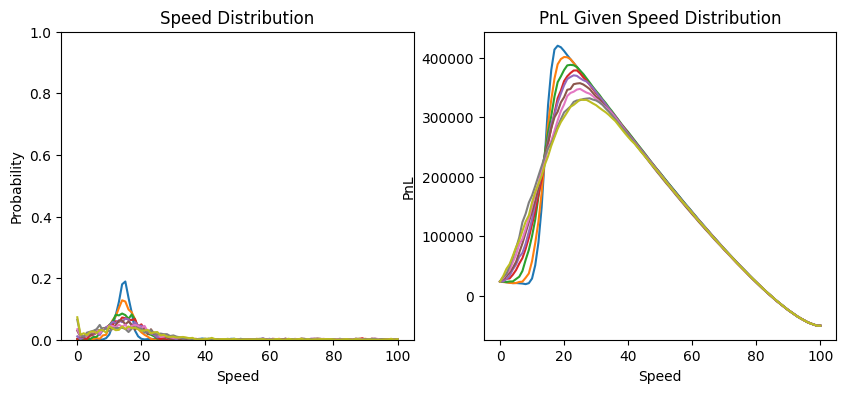

In [19]:
dists = [
    RandomDist(0, 100, 100) + NormalDist(15, std, 900)
    for std in range(2, 11, 1)
]
draw(*dists)

Top 5 PnL with Speed Distribution:
Speed: 31, PnL: 312145.82331287547
Speed: 32, PnL: 310910.9360718275
Speed: 33, PnL: 309802.43387890386
Speed: 34, PnL: 306472.57458234724
Speed: 30, PnL: 306457.61847333604
Top 5 PnL with Speed Distribution:
Speed: 34, PnL: 291675.112816168
Speed: 33, PnL: 289440.3983477645
Speed: 35, PnL: 289225.78876684746
Speed: 32, PnL: 289067.38692100876
Speed: 36, PnL: 286267.15673115617
Top 5 PnL with Speed Distribution:
Speed: 34, PnL: 274501.30512413
Speed: 35, PnL: 274112.21483021614
Speed: 36, PnL: 273806.13046567055
Speed: 37, PnL: 271611.6612079966
Speed: 33, PnL: 270815.69808301097
Top 5 PnL with Speed Distribution:
Speed: 37, PnL: 257890.31993936741
Speed: 36, PnL: 257419.22940258175
Speed: 35, PnL: 257338.24711067596
Speed: 38, PnL: 256787.04505931685
Speed: 34, PnL: 254902.68291217438
Top 5 PnL with Speed Distribution:
Speed: 36, PnL: 247870.33493505517
Speed: 35, PnL: 246168.96042446187
Speed: 38, PnL: 245786.58965816355
Speed: 37, PnL: 244962.21231

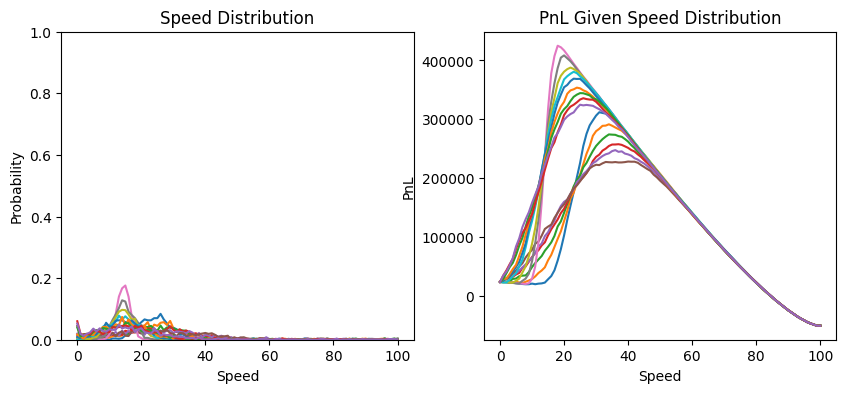

In [20]:
dists = [
    RandomDist(0, 100, 100) + NormalDist(25, std, 900)
    for std in range(5, 16, 2)
] + [
    RandomDist(0, 100, 100) + NormalDist(15, std, 900)
    for std in range(2, 11, 1)
]
draw(*dists)

Top 5 PnL with Speed Distribution:
Speed: 36, PnL: 177138.74542628686
Speed: 37, PnL: 175777.28449955166
Speed: 38, PnL: 175509.47449009508
Speed: 34, PnL: 174949.2025037843
Speed: 35, PnL: 174842.75082638522
Top 5 PnL with Speed Distribution:
Speed: 36, PnL: 174263.47727526212
Speed: 34, PnL: 174007.4687395598
Speed: 38, PnL: 173751.46020385742
Speed: 35, PnL: 173559.45380208062
Speed: 37, PnL: 173029.15040669718
Top 5 PnL with Speed Distribution:
Speed: 32, PnL: 170743.8993663393
Speed: 33, PnL: 170590.80795387918
Speed: 30, PnL: 170057.30757712427
Speed: 34, PnL: 169866.43875918913
Speed: 31, PnL: 169765.04215333684
Top 5 PnL with Speed Distribution:
Speed: 36, PnL: 172267.28095248336
Speed: 35, PnL: 171976.22970031181
Speed: 38, PnL: 170566.62853783378
Speed: 37, PnL: 170211.6601479304
Speed: 33, PnL: 169431.94865637246
Top 5 PnL with Speed Distribution:
Speed: 35, PnL: 172806.05483852592
Speed: 31, PnL: 171462.29097698882
Speed: 34, PnL: 171449.3158870518
Speed: 37, PnL: 171395.95

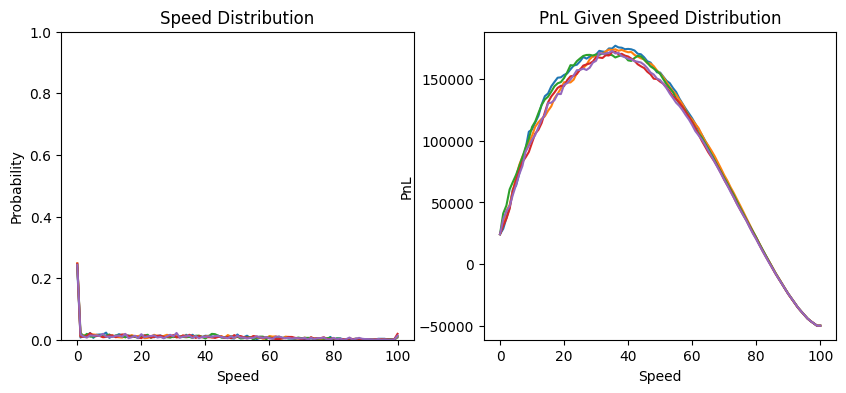

In [22]:
dist = [
    NormalDist(0, 10, 150) + NormalDist(20, 30, 600) + NormalDist(50, 25, 250)
    for _ in range(5)
]
draw(*dist)

Top 5 PnL with Speed Distribution:
Speed: 33, PnL: 239127.60482043057
Speed: 32, PnL: 239057.67628345074
Speed: 36, PnL: 236921.62248143158
Speed: 34, PnL: 236573.62139565218
Speed: 31, PnL: 236147.57332144416
Top 5 PnL with Speed Distribution:
Speed: 31, PnL: 239131.1908992501
Speed: 33, PnL: 238051.7811745871
Speed: 32, PnL: 237594.55612510367
Speed: 34, PnL: 237276.65389217634
Speed: 30, PnL: 237088.91901155718
Top 5 PnL with Speed Distribution:
Speed: 32, PnL: 240112.63944640534
Speed: 33, PnL: 239057.63255078223
Speed: 35, PnL: 238973.27707189776
Speed: 34, PnL: 238581.9794726129
Speed: 31, PnL: 238387.56060356222
Top 5 PnL with Speed Distribution:
Speed: 33, PnL: 235788.91772299213
Speed: 31, PnL: 234527.12083708058
Speed: 34, PnL: 234359.8245936496
Speed: 35, PnL: 233845.20588556828
Speed: 30, PnL: 232769.04110770603
Top 5 PnL with Speed Distribution:
Speed: 30, PnL: 238362.08321952587
Speed: 33, PnL: 237444.08916626085
Speed: 31, PnL: 236274.430401808
Speed: 32, PnL: 236250.249

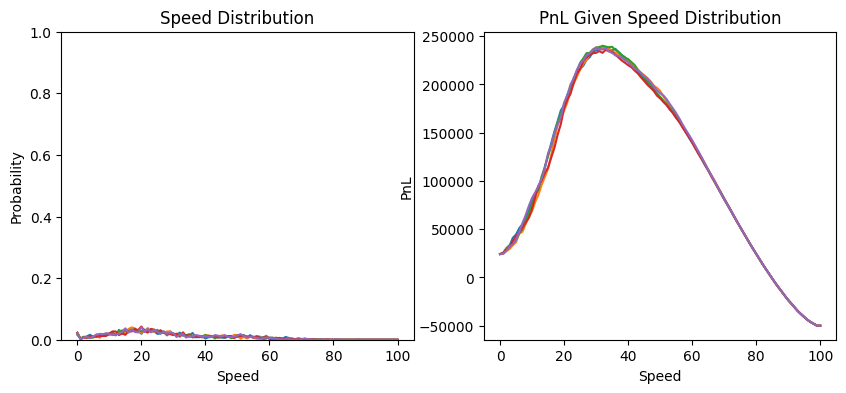

In [ ]:
dist = [
    NormalDist(20, 10, 750) + NormalDist(50, 10, 250)
    for _ in range(5)
]
draw(*dist)

Top 5 PnL with Speed Distribution:
Speed: 46, PnL: 158921.86865933568
Speed: 47, PnL: 158708.89005536263
Speed: 44, PnL: 157441.16026980837
Speed: 43, PnL: 157151.61463889404
Speed: 48, PnL: 156989.2008488898
Top 5 PnL with Speed Distribution:
Speed: 46, PnL: 160097.90368019458
Speed: 45, PnL: 158961.36955112807
Speed: 44, PnL: 158082.29173743882
Speed: 47, PnL: 158016.23386704596
Speed: 48, PnL: 157866.60712559766
Top 5 PnL with Speed Distribution:
Speed: 43, PnL: 166373.47707292123
Speed: 44, PnL: 166154.4779403633
Speed: 46, PnL: 166117.3675587968
Speed: 45, PnL: 165987.48122331421
Speed: 47, PnL: 165714.21386814315
Top 5 PnL with Speed Distribution:
Speed: 46, PnL: 165929.41082903554
Speed: 47, PnL: 165262.9516282951
Speed: 45, PnL: 164971.4283875161
Speed: 44, PnL: 163137.19111822153
Speed: 48, PnL: 163109.03626719821
Top 5 PnL with Speed Distribution:
Speed: 43, PnL: 168233.59058767415
Speed: 44, PnL: 166822.6717822435
Speed: 45, PnL: 166619.3994774874
Speed: 42, PnL: 165146.2393

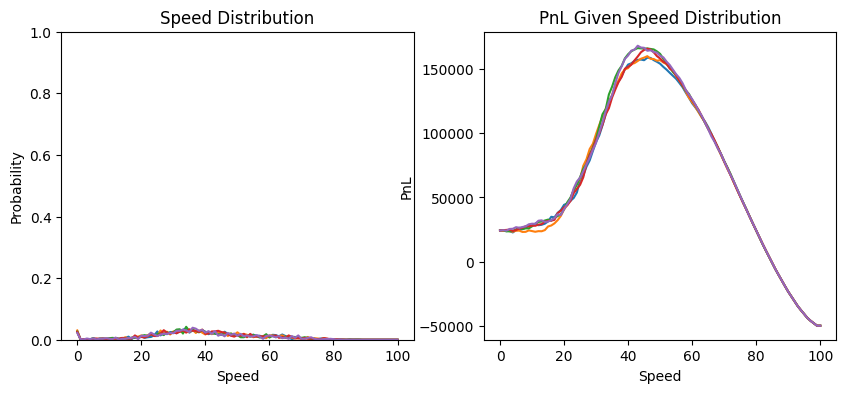

In [31]:
dist = [
    NormalDist(0, 10, 50) + NormalDist(35, 10, 700) + NormalDist(60, 10, 250)
    for _ in range(5)
]
draw(*dist)

Top 5 PnL with Speed Distribution:
Speed: 55, PnL: 112124.93318801915
Speed: 56, PnL: 111519.93857763402
Speed: 54, PnL: 111370.89354779077
Speed: 58, PnL: 109483.03875818019
Speed: 57, PnL: 109460.52573411938
Top 5 PnL with Speed Distribution:
Speed: 55, PnL: 114377.81925261364
Speed: 54, PnL: 113921.2075352153
Speed: 56, PnL: 113900.41610850368
Speed: 57, PnL: 112950.55269604546
Speed: 53, PnL: 112696.91237000198
Top 5 PnL with Speed Distribution:
Speed: 55, PnL: 110352.70092270104
Speed: 54, PnL: 109959.23586601796
Speed: 56, PnL: 108995.28670874532
Speed: 53, PnL: 108580.90121960055
Speed: 57, PnL: 108224.33649010671
Top 5 PnL with Speed Distribution:
Speed: 54, PnL: 107364.50498813827
Speed: 55, PnL: 107183.22056502014
Speed: 56, PnL: 106937.76466469205
Speed: 57, PnL: 106615.9423188493
Speed: 58, PnL: 104997.9961856133
Top 5 PnL with Speed Distribution:
Speed: 55, PnL: 115079.0003483656
Speed: 56, PnL: 114780.23073206388
Speed: 53, PnL: 114123.5766555932
Speed: 52, PnL: 114032.57

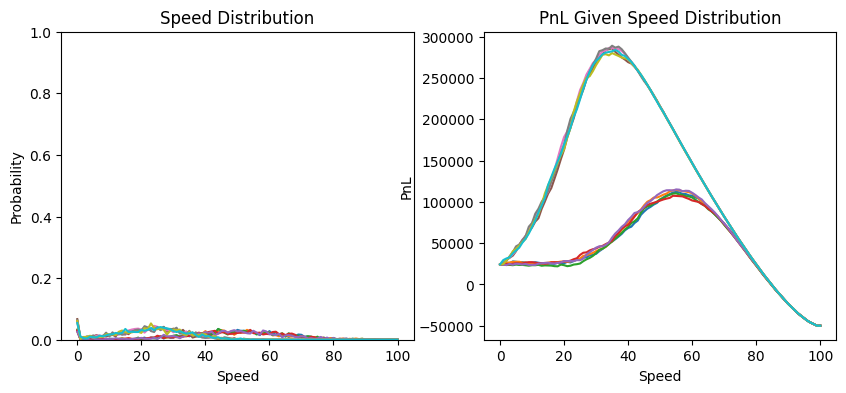

In [42]:
dist = [
    NormalDist(0, 10, 50) + NormalDist(50, 15, 950)
    for _ in range(5)
] + [
    NormalDist(0, 10, 100) + NormalDist(25, 10, 900)
    for _ in range(5)
]
draw(*dist)